# $K$-Means Clustering
As a part of the leadup to the nonparametric setting, we discussed alternate clustering algorithms. One of the classic models is $K$-means clustering. Here, we implement $k$-means from scratch.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

## Data generation
*The following code will be constant across the three notebooks.*

We pretend that the data is generated according to $$\pi\sim\text{Dir}(\alpha_1,\dots,\alpha_K)$$ $$z_i\sim\text{Cat}(\pi)$$ $$x_i|z_i=k \sim \mathcal{N}(\mu_k,I)$$ where we treat $K,\alpha_k$ as hyperparameters with hidden $\mu_k.$

In [2]:
# Hyperparameters
np.random.seed(14) # for reproducibility
K = 8 # number of clusters
alpha = np.random.choice(range(1,11), K) # hyperparameter for dirichlet distribution
N = 250 # number of data points
mu = np.random.uniform(-10, 10, (K, 2)) # cluster means
sigma = np.array([np.eye(2) for i in range(K)]) # cluster covariances

# Parameters for Gaussian Mixture Model
pi = np.random.dirichlet(alpha) # mixing proportions
z = np.random.choice(K, N, p=pi) # cluster assignments

# Generate data points
x = np.array([np.random.multivariate_normal(mu[z[i]], sigma[z[i]]) for i in range(N)]) # data points

In [3]:
def visualize(x, mu, z, iter):
    """
    Visualize the GMM with the current parameters
    """
    plt.scatter(x[:, 0], x[:, 1], c=z, cmap='viridis', s=50)
    plt.scatter(mu[:, 0], mu[:, 1], c='red', marker='x', s=200, label='Means')
    plt.title(f'GMM at iteration {iter}')
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.colorbar(label='Cluster Assignment')
    plt.show()

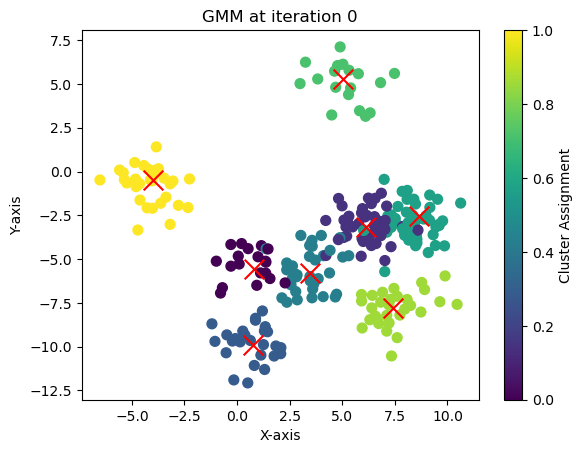

In [4]:
# Visualize the data
visualize(x, mu, z, 0)

## $K$-Means Clustering

We will initialize our priors and parameters, then define and run the Expectation-Maximization (EM) Algorithm.

Note that the responsibilities matrix, $R,$ which is in fact our posterior distribution, is defined as $$R_{ik}=p(z_i=k|x_i,\theta)=\frac{p(x_i|z_i=k,\theta)p(z_i=k|\theta)}{\sum_{k=1}^Kp(x_i|z_i=k,\theta)p(z_i=k|\theta)}$$ where $\theta$ represents our current parameters (i.e. means and covariances). In particular, $$p(z_i=k|\theta)=\hat\pi(k)$$ and $$p(x_i|z_i=k,\theta)=\mathcal{N}(x_i|\hat\mu_k,I_k).$$

To update the parameters, let $$N_k = \sum_{i=1}^n \mathbb{1}_{z_i=k}.$$ Then $$\hat\pi_k=\frac{N_k}{n}.$$ To update the means and covariances, we use $$\hat\mu_k = \frac{1}{N_k}\sum_{i=1}^n R_{ik}x_i.$$

In [10]:
np.random.seed(14) # for reproducibility
# Priors
alpha_hat = np.ones(K) # prior for dirichlet distribution
pi_hat = np.random.dirichlet(alpha_hat) # prior for mixing proportions
z_hat = np.random.choice(K, N, p=pi) # prior for cluster assignments

# Initialize parameters
mu_hat = x[np.random.choice(range(250), K)] # cluster means
responsibilities = np.zeros((N, K)) # responsibilities, given by the posterior

In [6]:
def expectation(X, mu, sigma, responsibilities, pi, K):
    """
    E-step: Calculate responsibilities using the current parameters
    """
    for k in range(K):
        responsibilities[:, k] = pi[k] * multivariate_normal.pdf(X, mean=mu[k], cov=sigma[k])
    responsibilities /= responsibilities.sum(axis=1, keepdims=True) # normalize
    return responsibilities

def maximization(X, responsibilities, N):
    """
    M-step: Update parameters using the current responsibilities
    """
    # Update mixing proportions
    N_k = responsibilities.sum(axis=0)
    pi_hat = N_k / N
    # Update means
    mu_hat = (np.dot(responsibilities.T, X).T / N_k).T
    return mu_hat, pi_hat

## Results

We visualize the results of EM at different stages.

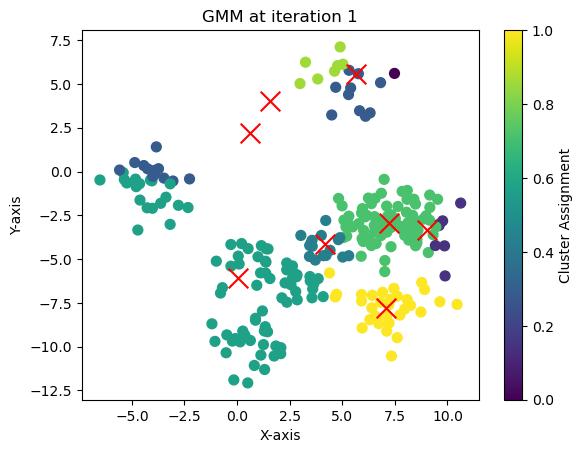

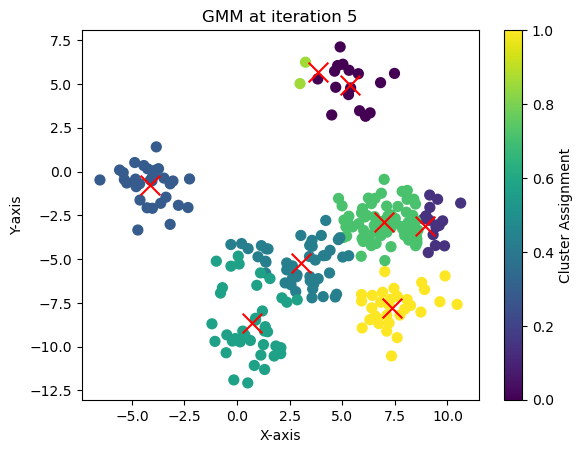

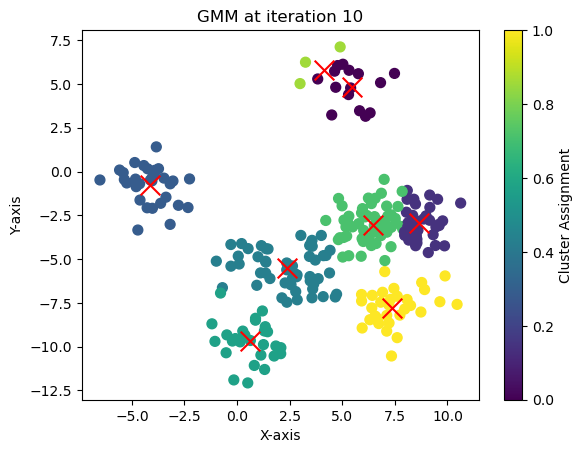

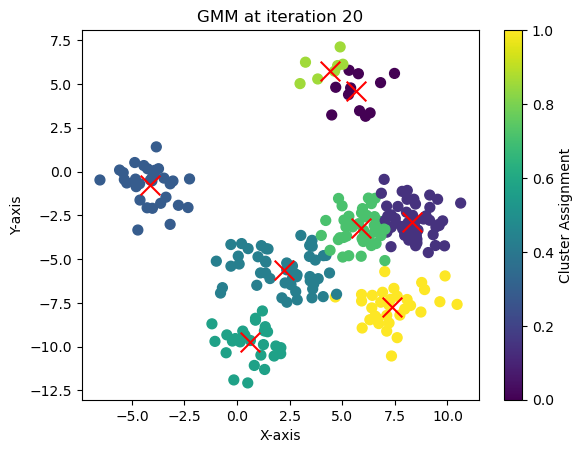

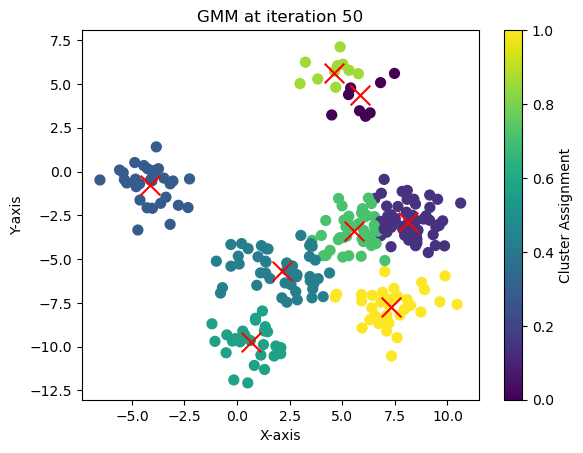

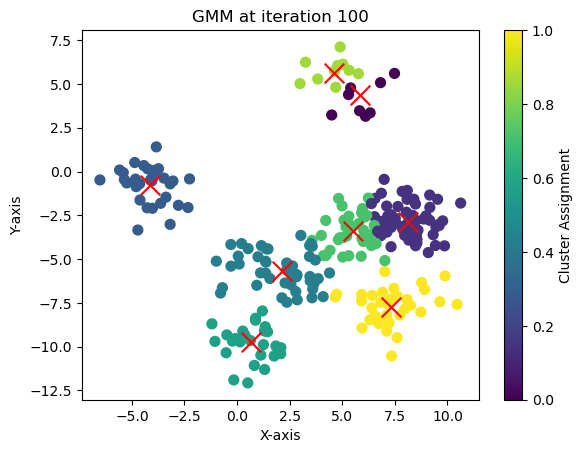

In [11]:
# Snapshots of parameters
snapshots = [1, 4, 5, 10, 30, 50]
# Run EM algorithm
for idx, itr in enumerate(snapshots):
    for i in range(itr):
        # E-step
        responsibilities = expectation(x, mu_hat, sigma, responsibilities, pi_hat, K)
        # M-step
        mu_hat, pi_hat = maximization(x, responsibilities, N)
    visualize(x, mu_hat, np.argmax(responsibilities, axis=1), sum(snapshots[:idx+1]))

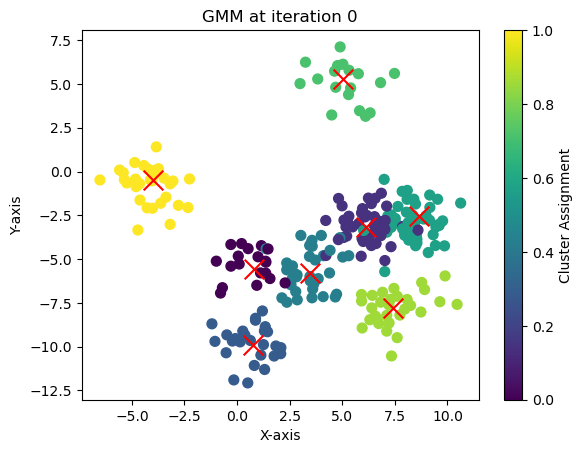

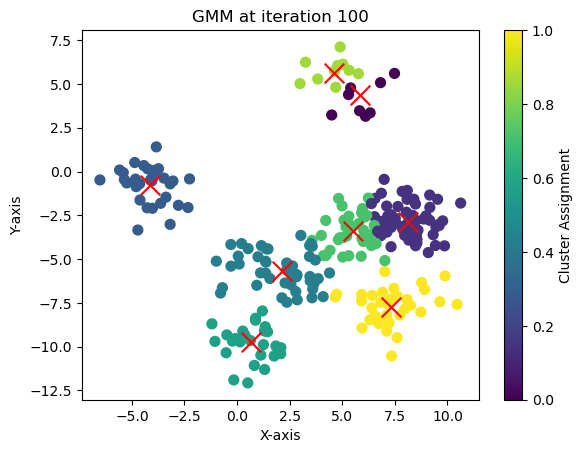

In [12]:
visualize(x, mu, z, 0)
visualize(x, mu_hat, np.argmax(responsibilities, axis=1), sum(snapshots))